### Preparation

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from tqdm import tqdm
from mltclass import QuantumNeuron, QuantumNetwork
from mltclass.utils import load_dataset, normalize_dataset, plot_history, plot_weights

In [2]:
# Hyperparameters
num_epochs = 250
num_hidden = 30
batch_size = 512
learning_rate = 0.05
dataset = "MNIST" # Available (MNIST, Fashion, CIFAR)
rng = np.random.default_rng(2026)
torch.manual_seed(2025)
balanced_dataset = False
use_bias_sigmoid = True
trainval_ratio = 0.8  # Ratio 80% training, 20% validation

### Dataset

In [3]:
def get_bisection(classes: list, rng):
    """
    Recursively generate a random binary tree over classes.
    Returns a nested tuple structure.
    """
    if len(classes) == 1:
        return classes[0]
    rng.shuffle(classes) # Shuffle before splitting
    # Split nodes
    mid = len(classes) // 2
    left = classes[:mid]
    right = classes[mid:]

    return (get_bisection(left, rng), get_bisection(right, rng))

def get_leaves(subtree):
    """
    Return a list of leaves in the subtree.
    """
    if isinstance(subtree, int):
        return [subtree] # Single leave
    left, right = subtree
    return get_leaves(left) + get_leaves(right)

def get_nodes(tree, max_depth, current_depth=0):
    """
    Return all the binary nodes at a given depth.
    """
    if current_depth == max_depth:
        return [get_leaves(tree)]
    if isinstance(tree, int):
        return [] # Stop at leaves

    left, right = tree
    return (get_nodes(left, max_depth, current_depth+1) + get_nodes(right, max_depth, current_depth+1))

def get_tree(labels: np.ndarray):
    """
    Generate the binary decision tree.
    """
    partition = get_bisection(labels.tolist(), rng)
    depth, tree = 0, []
    # print('Tree')
    while True:
        node = get_nodes(partition, depth)
        if node != []:
            tree.append(node)
            # print(f"Depth {depth}: {node}")
            depth += 1
        elif node == []: # Stops with empty leaves
            break
    return tree, partition, depth

In [4]:
def plant_tree(user_X: np.ndarray, user_Y: np.ndarray, test_X: np.ndarray, test_Y: np.ndarray, tree, depth: float,\
               generator, verbose: bool = True):
    X, Y = [], []
    istraining = True # Verbose only for training
    
    for data_X, data_Y in [(user_X, user_Y), (test_X, test_Y)]:
        tmplist_X , tmplist_Y = [], []
        counter, legend = 0, {}
        for d in range(1, depth): # Main training loop
            if istraining and verbose: print(f"Depth: {d} -> {tree[d]}")
            for idx in range(0, len(tree[d]) - 1, 2): # Loop over leaves
                zeros = tree[d][idx]
                ones = tree[d][idx + 1]
                zero_idx = np.where(np.isin(data_Y[:,0], zeros))[0]
                one_idx = np.where(np.isin(data_Y[:,0], ones))[0]

                # Create binary models. Keep track of the original multinomial labels for navigating the decision tree with flattened models
                if not istraining: legend[counter] = zeros + ones # Multinomial labels included in the node, e.g. [3,[4,5]] (Test only)
                tmp_X = np.vstack((data_X[zero_idx], data_X[one_idx]))
                tmp_Y = np.vstack((np.zeros((len(zero_idx), 1)), np.ones((len(one_idx), 1)))) # Binarized labels, e.g. [3,[4,5]] -> [0,1]
                if istraining and verbose:
                    print('Class 0:', np.unique(data_Y[zero_idx]))
                    print('Class 1:', np.unique(data_Y[one_idx]))
                    print('---')
                
                shuffled = generator.permutation(tmp_X.shape[0])
                tmplist_X.append(torch.tensor(tmp_X[shuffled], dtype=torch.float64))
                tmplist_Y.append(torch.tensor(tmp_Y[shuffled], dtype=torch.float64))
                counter += 1
                
        istraining = False       
        X.append(tmplist_X)
        Y.append(tmplist_Y)
    
    return (len(X[0]), legend), (X[0], Y[0]), (X[1], Y[1])

In [5]:
(X, Y), (XAll, YAll) = load_dataset(dataset, download = False)
(num_classes, _), (X0, Y0), (X1, Y1) = normalize_dataset(X, Y, XAll, YAll)
classes = np.arange(num_classes)
# classes = rng.choice(range(num_classes), size=8, replace = False)
tree, partition, depth = get_tree(classes)

In [6]:
(num_models, idx2labels), (Xtrain, Ytrain), (Xval, Yval) = plant_tree(X0, Y0, X1, Y1, tree, depth, rng, verbose = False)
train_loader = [DataLoader(TensorDataset(X, Y), batch_size=batch_size, shuffle=True) for X, Y in zip(Xtrain, Ytrain)]
val_loader = [DataLoader(TensorDataset(X, Y), batch_size=batch_size, shuffle=False) for X, Y in zip(Xval, Yval)]
print('Legend') # Map from indexes to labels
for key in idx2labels.keys():
    print(f"Models {key} -> {idx2labels[key]}")
tree_map = {tuple(v): k for k, v in idx2labels.items()} # Inverse map from labels to indexes

Legend
Models 0 -> [9, 6, 8, 0, 1, 4, 7, 2, 5, 3]
Models 1 -> [9, 6, 8, 0, 1]
Models 2 -> [4, 7, 2, 5, 3]
Models 3 -> [9, 6]
Models 4 -> [8, 0, 1]
Models 5 -> [4, 7]
Models 6 -> [2, 5, 3]
Models 7 -> [0, 1]
Models 8 -> [5, 3]


### Model

In [7]:
history_train = torch.zeros((num_models,num_epochs,2), dtype=torch.float64)
history_val = torch.zeros((num_models,num_epochs,2), dtype=torch.float64)
hidden_weights, output_weights, models, optimizer = [], [], [], []
for idx in tqdm(range(num_models)):
    models.append(QuantumNetwork(Xtrain[idx].shape[1], num_hidden, use_bias_sigmoid = use_bias_sigmoid)) # Model
    loss_function = torch.nn.BCELoss() # Loss
    optimizer.append(torch.optim.SGD(models[idx].parameters(), lr = learning_rate)) # Optimizers
    (tmptorchHid, tmptorchOut), history_train[idx,:,:], history_val[idx,:,:] = models[idx].train(train_loader[idx], val_loader[idx], \
                                                                               num_epochs, loss_function, optimizer[idx]) # Train
    hidden_weights.append(tmptorchHid) 
    output_weights.append(tmptorchOut.squeeze(0)) # Squeeze 
hidden_weights = torch.stack(hidden_weights)
output_weights = torch.stack(output_weights)
del tmptorchHid, tmptorchOut

100%|██████████| 9/9 [09:01<00:00, 60.21s/it] 


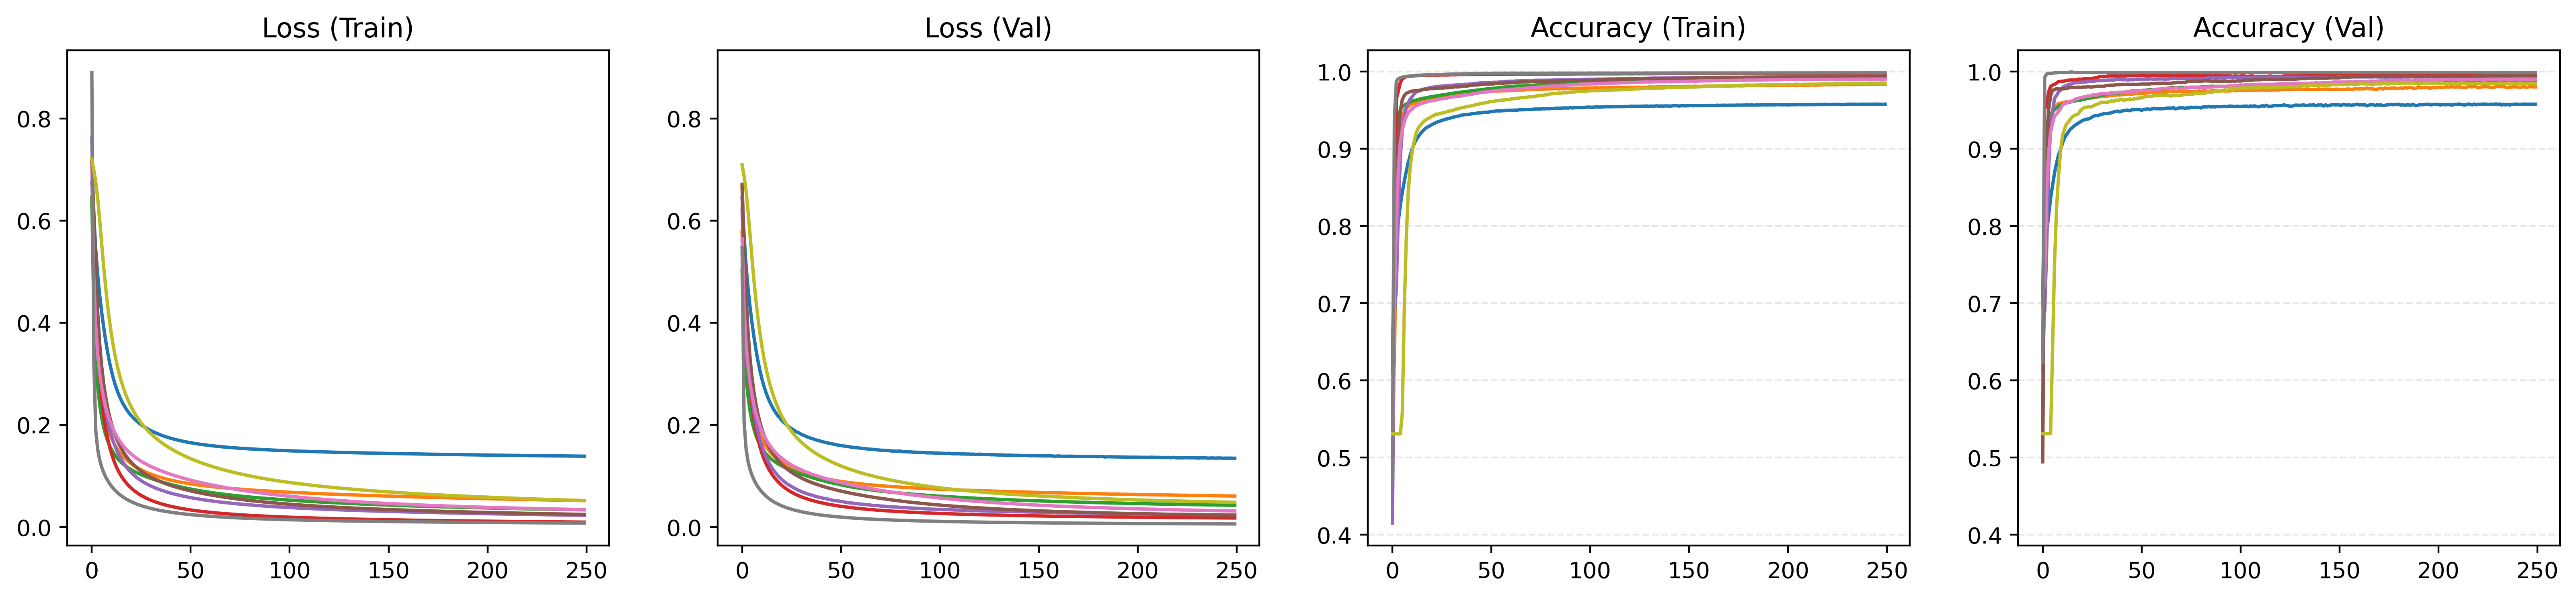

In [8]:
plot_history(history_train, history_val, show_legend = False)

### Classification

In [9]:
def get_multinomial(x, models, tree, partition, label2idx):
    """
    Recursively evaluate the tree and predict the multinomial label.
    """
    def flatten(x: tuple):
        """
        Recursively flatten a given tuple, e.g. ((5,8),(1,(4,6))) -> (5,8,1,4,6).
        """
        for item in x:
            if isinstance(item, tuple):
                yield from flatten(item)
            else:
                yield item
                
    if isinstance(partition, int):
        return partition # Return leaves
    
    node_labels = tuple(flatten(partition)) # Available labels in the node
    node_idx = label2idx[node_labels] # Flattened index

    left, right = partition
    out = models[node_idx](x).item()
    if out <= 0.5: # Go left
        return get_multinomial(x, models, tree, left, label2idx)
    else: # Go right
        return get_multinomial(x, models, tree, right, label2idx)

In [10]:
acc = 0
res = [] 
mask = np.isin(Y1[:,0], classes)
filtX1 = X1[mask,:]
filtY1 = Y1[mask,:]
for x, y in zip(filtX1, filtY1):
    y_pred = get_multinomial(x, models, tree, partition, tree_map)
    res.append(y_pred)
    acc += int(y_pred == int(y.item()))/len(filtY1) * 100 
print(f"Accuracy is {acc:.2f}")

Accuracy is 93.83


In [11]:
def get_accuracy(models, test_X, test_Y, num_classes, num_models, mode):
    accuracy = {mode: []}
    comb = torch.tensor([(i, j) for i in range(num_classes) for j in range(i + 1, num_classes)]) # Label combinatorics (for mode = "one_vs_one")
    for idx in range(num_classes):
        mask = (test_Y[:, 0] == idx).squeeze() # Mask classes
        X = test_X[mask].reshape(mask.sum(), -1) # Mask dataset
        out = torch.zeros(X.shape[0], num_models) # Binary model outputs
        bin_pred = torch.zeros(X.shape[0], num_models, dtype = int) 
        label_pred = torch.zeros_like(bin_pred) 
    
        # Compute the predictions of each binary model
        res = []
        for x in X:
            with torch.no_grad():
                out = get_multinomial(x, models, tree, partition, tree_map)
                res.append(out)
        mdl_pred = torch.tensor(res)
        tmp = (mdl_pred == test_Y[mask, 0]).float().mean() * 100
        accuracy[mode].append(float(tmp)) # Accuracy per class

    accuracy[mode].append(np.mean(accuracy[mode])) # Accuracy averaged over classes
    return accuracy

In [12]:
acc = get_accuracy(models, X1, Y1, num_classes, num_models, None) # Per-class and averaged accuracies
df = pd.DataFrame.from_dict(acc)
df = df.rename(index={df.index[-1]: 'Avg.'})
df.style.format("{:.2f}")#.set_caption("Accuracy")

,None
0,96.73
1,98.68
2,92.15
3,94.95
4,90.63
5,92.15
6,95.93
7,93.77
8,91.79
9,90.78
